In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "matriz_final_v3_survivorship.csv",
    sep=",",
    index_col=0,     
    parse_dates=True
)

split_idx = int(len(df) * 0.8)
df = df.iloc[split_idx:]

# ajustando as colunas
numeric_cols = df.columns[df.dtypes != "object"]
df_numeric = df[numeric_cols]

In [4]:
# calcular retornos
returns = df_numeric.pct_change().dropna()
returns.describe()

,AAPL,ABBV,ABT,ACN,ADBE,AIG,AMD,AMGN,AMT,AMZN,...,UBER,UNH,UNP,UPS,USB,V,VZ,WFC,WMT,XOM
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,...,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,0.000471,0.001296,0.000523,-0.000922,-0.000738,0.000915,0.002883,0.001211,-0.000013,0.000336,...,0.001350,-0.001191,0.000316,-0.000430,0.000841,0.000562,0.000380,0.001419,0.001007,0.000705
std,0.020527,0.016329,0.013973,0.017758,0.019281,0.015435,0.038237,0.017340,0.015440,0.021739,...,0.024031,0.029874,0.014080,0.020582,0.017050,0.014222,0.013295,0.018334,0.015895,0.014761
min,-0.092456,-0.072803,-0.085244,-0.072611,-0.138532,-0.084107,-0.088967,-0.058376,-0.054780,-0.089791,...,-0.075556,-0.223797,-0.060765,-0.141127,-0.098117,-0.077374,-0.065821,-0.091198,-0.065288,-0.071956
25%,-0.007116,-0.006642,-0.005980,-0.009939,-0.008066,-0.005952,-0.017013,-0.007218,-0.007446,-0.011211,...,-0.011693,-0.011124,-0.007018,-0.009047,-0.005544,-0.005191,-0.006547,-0.006353,-0.007103,-0.006756
50%,0.000746,0.000391,0.001013,-0.000453,0.000113,0.001430,0.001629,0.001960,0.000486,0.000346,...,0.001088,-0.000148,0.001116,0.000540,0.001473,0.001190,0.000477,0.001921,0.000919,0.001354
75%,0.006698,0.009963,0.007516,0.008723,0.008586,0.008846,0.018501,0.010143,0.008316,0.012391,...,0.014228,0.012200,0.007788,0.010143,0.008895,0.008131,0.008247,0.011406,0.009041,0.010180
max,0.153288,0.055455,0.046188,0.065923,0.072471,0.066306,0.238205,0.078059,0.061198,0.119770,...,0.116951,0.119783,0.073270,0.084204,0.079670,0.078373,0.041375,0.071465,0.095489,0.049916


In [5]:
# estratégia 1/N

n_assets = returns.shape[1]
weights_1N = np.ones(n_assets) / n_assets

portfolio_returns_1N = returns @ weights_1N
cumulative_returns_1N = (1 + portfolio_returns_1N).cumprod()

# métricas de performance

risk_free_rate = 0.0

annual_return = portfolio_returns_1N.mean() * 252 #retorno anualizado
volatility = portfolio_returns_1N.std() * np.sqrt(252) #volatilidade anualizada
sharpe_ratio = (annual_return - risk_free_rate) / volatility # sharpe ratio

# máximo drawdown
cum_max = cumulative_returns_1N.cummax()
drawdown = cumulative_returns_1N / cum_max - 1
max_drawdown = drawdown.min()

print("Estratégia 1/N")
print(f"Retorno anualizado: {annual_return:.2%}")
print(f"Volatilidade anualizada: {volatility:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Máximo Drawdown: {max_drawdown:.2%}")

Estratégia 1/N
Retorno anualizado: 18.82%
Volatilidade anualizada: 16.66%
Sharpe Ratio: 1.13
Máximo Drawdown: -15.56%


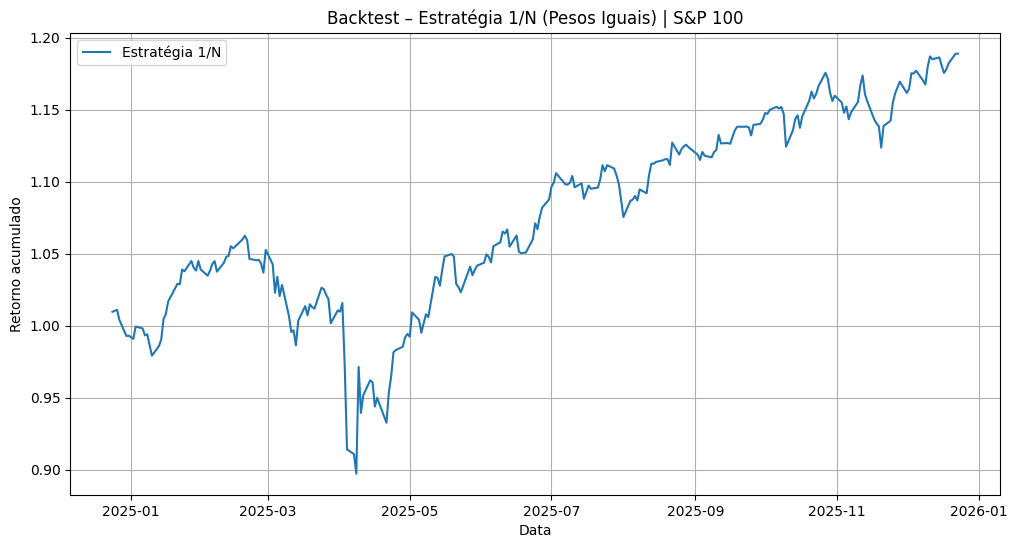

In [6]:
# gráfico
plt.figure(figsize=(12, 6))
plt.plot(cumulative_returns_1N, label="Estratégia 1/N")
plt.title("Backtest – Estratégia 1/N (Pesos Iguais) | S&P 100")
plt.xlabel("Data")
plt.ylabel("Retorno acumulado")
plt.legend()
plt.grid(True)
plt.show()